In [10]:
#!pip install UUID7

In [33]:
from langgraph.graph import StateGraph, START,END
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from typing import TypedDict, Annotated
from operator import add
from langsmith import traceable
import os
from dotenv import load_dotenv


In [34]:
load_dotenv()

os.environ["LANGSMITH_PROJECT"] = "langgraph: 9_trace_langsmith_integration"

In [35]:
class StateSchema(TypedDict):
    messages: Annotated[list[BaseMessage], add]

In [36]:
llm = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite",
    temperature=0.6
)


In [37]:
@traceable(name = "llm_chat_node")
def llm_node(state: StateSchema):
    chats = state["messages"]

    resp = llm.invoke(chats)

    return {
        "messages": [resp]
    }


In [38]:
conn = sqlite3.connect(database = 'chatbot.db', check_same_thread = False)

checkpointer = SqliteSaver(conn=conn)

In [39]:
graph = StateGraph(StateSchema)\
    .add_node("llm_chat_bot", llm_node)\
    .add_edge(START, "llm_chat_bot")\
    .add_edge("llm_chat_bot", END)\
    .compile(checkpointer=checkpointer)

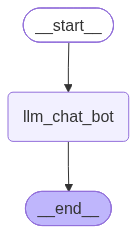

In [29]:
graph


# Thread ID in LangGraph

A **thread ID** uniquely identifies a conversation/workflow execution.

It tells the checkpointer **which saved state belongs to which conversation**.

### Example

```python
config = {
    "configurable": {
        "thread_id": "user-1"
    }
}
````

Using the same `thread_id`:

```text
user-1
  ↓
Checkpoint 1
  ↓
Checkpoint 2
  ↓
Checkpoint 3
```

The chatbot can access the previous conversation state.

Different `thread_id`s create separate conversations:

```text
user-1 → Conversation A

user-2 → Conversation B
```

### Important

> **Thread ID = identity of a conversation/state history.**

It works together with a **checkpointer** to maintain conversation state across multiple graph invocations.



In [ ]:
# multiple chat session

@traceable(name="config_builder")
def configBuilder(thread_id: str = None): 
    id = thread_id if thread_id else "xyz"
    config = {
        "configurable": {
            "thread_id": id
        },
        "tags": ["chatbot", "gemini"],
        "metadata": {
            "file": "9_trace_langsmith_integration.ipynb",
            "thread_id": id
        }
    }
    return config


# Thread ID in LangSmith

A **thread ID** helps LangSmith group multiple LangGraph runs that belong to the **same conversation**.

### Example

```python
config = {
    "configurable": {
        "thread_id": "user-1"
    }
}
````

LangSmith can then show:

```text
Thread: user-1
   ├── Run 1 → User: Hi
   ├── Run 2 → User: My name is Rahul
   ├── Run 3 → User: What is my name?
   └── Run 4 → AI response
```

### Why useful?

* Groups runs belonging to the same conversation.
* Makes it easier to **trace and debug** a chatbot conversation.
* Lets you inspect the complete execution history of a thread.
* Helps analyze how state and memory are being used across runs.

> **Thread ID = connects multiple LangGraph runs into one conversation in LangSmith.**



In [42]:
CONFIG = None

while True:
    msg = input()

    if msg is None:
        continue
    elif msg.lower() in ["exit", "done", "stop", "bye"]:
        break
    elif msg.strip().lower() == "change":
        thread_id = input()
        CONFIG = configBuilder(thread_id)
        continue

    if CONFIG is None:
        CONFIG = configBuilder()

    initial_message = {"messages": [HumanMessage(content=msg)]}
    resp = graph.invoke(initial_message, CONFIG)


    print("\nUser: ", msg)

    print("AI: ", resp["messages"][-1].content[0]["text"])





In [45]:
for cp in checkpointer.list(CONFIG):
    print(cp)

CheckpointTuple(config={'configurable': {'thread_id': 'xyz', 'checkpoint_ns': '', 'checkpoint_id': '1f19af7a-3b70-6713-8016-a36ccfa9ff1b'}}, checkpoint={'v': 4, 'ts': '2026-08-18T11:26:21.947660+00:00', 'id': '1f19af7a-3b70-6713-8016-a36ccfa9ff1b', 'channel_values': {'messages': [HumanMessage(content='my name is bhavin', additional_kwargs={}, response_metadata={}), AIMessage(content=[{'type': 'text', 'text': "Hello, Bhavin! It's a pleasure to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EnEKbwERTTIPWcHjJED9FsvD1/mXCSyOyOJrArNSGMqH60XTg8N3kgZ87nywHKcboA5Lkz11Z80dXlY69WZh2/08az0OuBFUO1i49T8r5iyOf1lm7EEkjSeykpXsJSo2socrXzzWMbl1fJhJbxsJVaxkPg=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a01495-7858-7ee1-b9fe-63851c07f38e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'o